In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import pint
#import QuickSymbols as qs

In [2]:
ureg = pint.UnitRegistry()

string_length = 0.9 * ureg.meter

string_diameter = 0.51 * ureg.millimeter
string_radius = string_diameter/2
string_radius_m = string_radius.to(ureg.meter)


print(f"L = {string_length}")
print(f"r = {string_radius_m}")

L = 0.9 meter
r = 0.000255 meter


In [3]:
disc_s_ten_period_min = (3*ureg.minutes + 33*ureg.second).to(ureg.second)
disc_s_period = (disc_s_ten_period_min/10).to(ureg.second)

print(f"tau = {disc_s_period}")

tau = 21.3 second


In [4]:
disc_ss_mass = 1.23 * ureg.kilogram
disc_s_radius = (9 * ureg.centimeter).to(ureg.meter)

disc_ss_moment_of_inirtia = (1/2) * disc_ss_mass * (disc_s_radius**2)
  
print(f"I = {disc_ss_moment_of_inirtia}")

I = 0.0049815 kilogram * meter ** 2


In [5]:
disc_ss_period = ((4*ureg.minute + 2*ureg.second)/10).to(ureg.second)
print(f"{'tau'}' = {disc_ss_period}")

tau' = 24.2 second


$\phi = \frac{8 \pi L I'}{r^4 (\tau'^2 - \tau^2)}$


In [6]:
phi_twist_modul = (8 * np.pi * string_length * disc_ss_moment_of_inirtia) / ( (string_radius_m**4) * ((disc_ss_period**2) - ( disc_s_period**2)) )
phi_twist_modul = phi_twist_modul.to(ureg.newton/(ureg.meter**2))

In [7]:
print(f"{'phi_twist_modul'} = {format(phi_twist_modul, 'e')}", f"np.pi = {np.pi}", f"disc_ss_moment_of_inirtia = {disc_ss_moment_of_inirtia}", f"r (s') = {string_radius_m}", f"disc_ss_period = {disc_ss_period}", f"disc_s_period = {disc_s_period}", f"L = {string_length}",sep="\n")


phi_twist_modul = 2.019633e+11 newton / meter ** 2
np.pi = 3.141592653589793
disc_ss_moment_of_inirtia = 0.0049815 kilogram * meter ** 2
r (s') = 0.000255 meter
disc_ss_period = 24.2 second
disc_s_period = 21.3 second
L = 0.9 meter


Bending Elasticity

In [8]:
m_data = np.array([0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]) * ureg.kilogram
g = 10 * ureg.meter / ureg.second**2
F_data = (m_data * g).to(ureg.newton)
y_0 = 18 * ureg.centimeter
rod_length = (85 * ureg.centimeter).to(ureg.meter)
rod_radius = 0.001725 * ureg.meter

y_values = np.array([[18, 18],
                     [17.7,17.8],
                     [17.3, 17.4], 
                     [16.8, 16.95], 
                     [16.4, 16.4], 
                     [15.8, 16], 
                     [15.5, 15.6]]) * ureg.centimeter

print(f"Y_values = {y_values}")
y_average = np.mean(y_values, axis=1)

print(f"F = {F_data}")

print(f"Y_average = {y_average}")
y_calibrated = abs(y_average - y_0)
print(f"Y = {y_calibrated}")

Y_values = [[18.0 18.0] [17.7 17.8] [17.3 17.4] [16.8 16.95] [16.4 16.4] [15.8 16.0] [15.5 15.6]] centimeter
F = [0.0 0.5 1.0 1.5 2.0 2.5 3.0] newton
Y_average = [18.0 17.75 17.35 16.875 16.4 15.9 15.55] centimeter
Y = [0.0 0.25 0.6499999999999986 1.125 1.6000000000000014 2.0999999999999996 2.4499999999999993] centimeter


In [9]:
model = LinearRegression()
model.fit(y_calibrated.reshape(-1,1), F_data.reshape(-1, 1))
y_space_line = np.linspace(y_calibrated[0], y_calibrated[-1]+(0.5*ureg.centimeter), 10000).reshape(-1,1)
F_model_line = model.predict(y_space_line) * ureg.newton
print(F_model_line)

[[0.14619630843539788] [0.1465383126202911] [0.14688031680518432] ... [3.5652121448128935] [3.5655541489977867] [3.56589615318268]] newton


c:\Users\Pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\_array_api.py:521: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array = numpy.asarray(array, order=order, dtype=dtype)
c:\Users\Pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\_array_api.py:521: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array = numpy.asarray(array, order=order, dtype=dtype)
c:\Users\Pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\_array_api.py:521: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array = numpy.asarray(array, order=order, dtype=dtype)


In [10]:
F_constant = 1.0 * ureg.newton

$F = \sin \theta$

c:\Users\Pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\ma\core.py:2826: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\Pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\cbook.py:1345: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


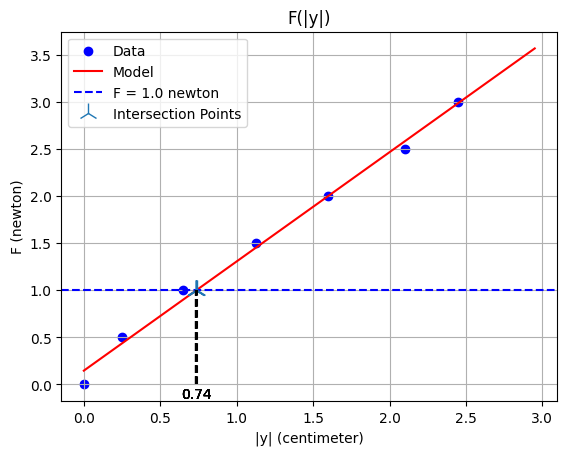

In [11]:
 # Example model (replace with your actual model)
 # Constant value to intersect

# Find intersection points
intersection_indices = np.where(np.isclose(F_model_line, F_constant, atol=1e-3))
intersection_y_values = y_space_line[intersection_indices]

# Plotting the data and model
plt.title("F(|y|)")
plt.scatter(y_calibrated, F_data, c="blue", label="Data")
plt.plot(y_space_line, F_model_line, c="red", label="Model")
plt.xlabel(f"|y| ({y_calibrated.units})")
plt.ylabel(f"F ({F_data.units})")

# Adding the constant line and intersection points
plt.axhline(y=F_constant.magnitude, color='blue', linestyle='--', label=f'F = {F_constant}')

# Mark the intersection points on the graph
plt.plot(intersection_y_values, [F_constant.magnitude] * len(intersection_y_values), '2', label='Intersection Points', ms=15, linewidth=6)

# Add vertical lines and annotate x-axis
Y_F_1 = 0

for y_val in intersection_y_values.magnitude:
    plt.plot([y_val, y_val], [0, F_constant.magnitude], 'k--')  # Vertical line
    plt.text(float(y_val), -0.15, str(round(float(y_val), 2)), ha='center')  # Annotation on x-axis
    Y_F_1 = y_val * ureg.meter

plt.legend()
plt.grid(True)
plt.show()

$Y = \frac{L^3 F}{12 \pi r^4 E} \Rightarrow$ $E = \frac{L^3 F}{12 \pi r^4 Y}$

In [12]:
print(round(Y_F_1, 2))
print(rod_length)
print(F_constant)
print(rod_radius)

0.74 meter
0.85 meter
1.0 newton
0.001725 meter


In [13]:
E_young_modul = ((rod_length**3)*F_constant)/(12*np.pi*(rod_radius**4 * Y_F_1))
print(f"E = {E_young_modul:e}")

E = 2.495385e+09 newton / meter ** 2


In [15]:
%whos

Variable                    Type                Data/Info
---------------------------------------------------------
E_young_modul               Quantity            2495384982.010575 newton / meter ** 2
F_constant                  Quantity            1.0 newton
F_data                      Quantity            [0.0 0.5 1.0 1.5 2.0 2.5 3.0] newton
F_model_line                Quantity            [[0.14619630843539788] [0<...>3.56589615318268]] newton
LinearRegression            ABCMeta             <class 'sklearn.linear_mo<...>._base.LinearRegression'>
PolynomialFeatures          type                <class 'sklearn.preproces<...>mial.PolynomialFeatures'>
Y_F_1                       Quantity            0.737278727872787 meter
disc_s_period               Quantity            21.3 second
disc_s_radius               Quantity            0.09 meter
disc_s_ten_period_min       Quantity            213.0 second
disc_ss_mass                Quantity            1.23 kilogram
disc_ss_moment_of_inirtia   